Dataset Created Successfully

      Zone Building_Type  Temperature_C  Occupancy_Rate  Solar_Capacity_kW  \
0     West    Commercial      31.978399              55          14.248936   
1  Central        Public      27.246659              87           3.844527   
2     East   Residential      33.772081              26           0.152498   
3  Central        Public      30.445294              73          11.716980   
4  Central   Residential      29.431831              20           3.191395   

   Traffic_Index  EV_Charging_Sessions  Waste_Generated_kg  \
0            275                     9         1026.135743   
1           1289                     8          668.091087   
2            756                     5          638.781669   
3            941                     8         1117.377534   
4            469                     9         1034.545636   

   Energy_Consumption_kWh  Renewable_Energy_Percent  Sustainability_Score  \
0             2478.639334                100.000000

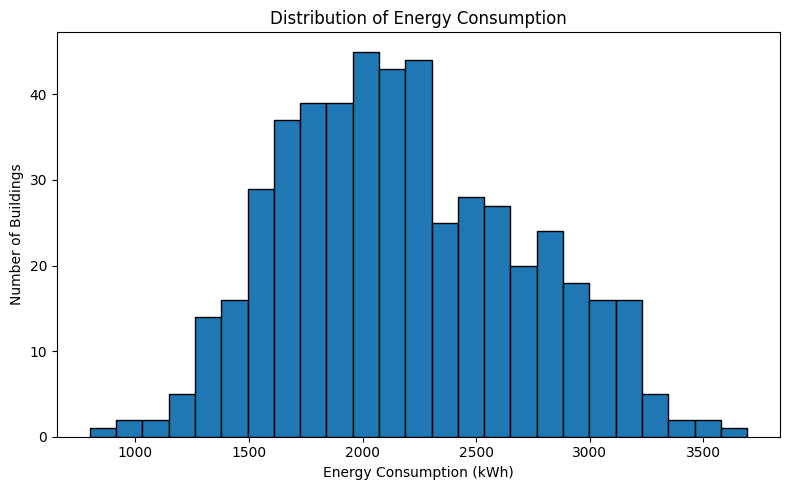


RANDOM FOREST CLASSIFICATION

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


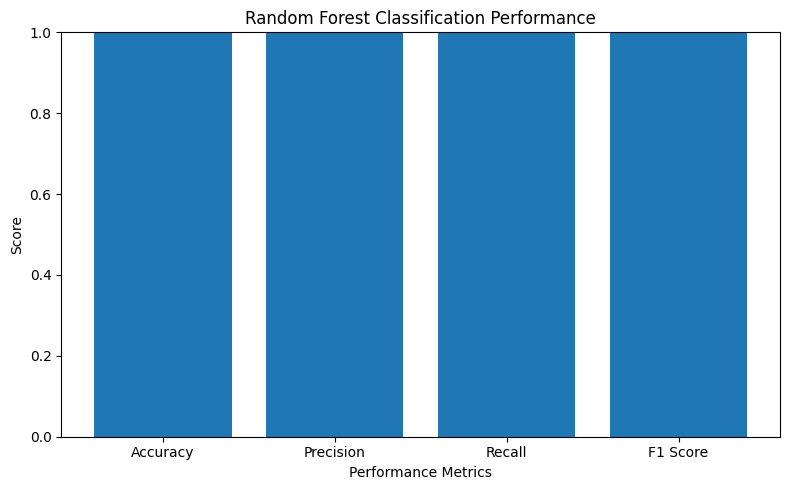


CONFUSION MATRIX
[[88  0]
 [ 0 37]]


<Figure size 700x500 with 0 Axes>

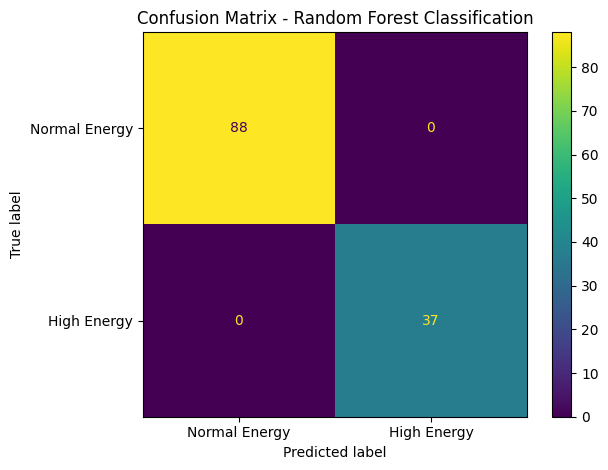

K = 2 Silhouette Score = 0.301
K = 3 Silhouette Score = 0.304
K = 4 Silhouette Score = 0.26
K = 5 Silhouette Score = 0.258
K = 6 Silhouette Score = 0.253

Best Number of Clusters: 3


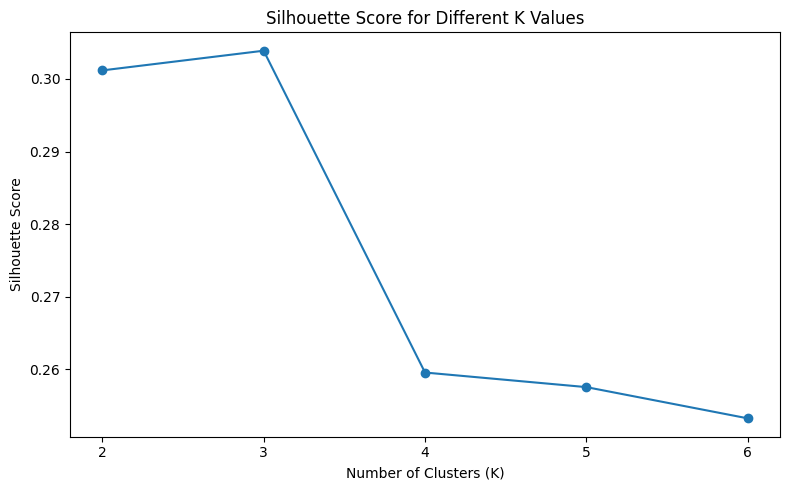


CLUSTER SUMMARY

         Energy_Consumption_kWh  Waste_Generated_kg  Renewable_Energy_Percent  \
Cluster                                                                         
0                       2695.95              929.66                     99.85   
1                       1843.78              856.31                     99.95   
2                       2922.09              979.93                     35.61   

         EV_Charging_Sessions  Sustainability_Score  
Cluster                                              
0                        8.17                 69.93  
1                        7.68                 92.61  
2                        8.50                 32.92  


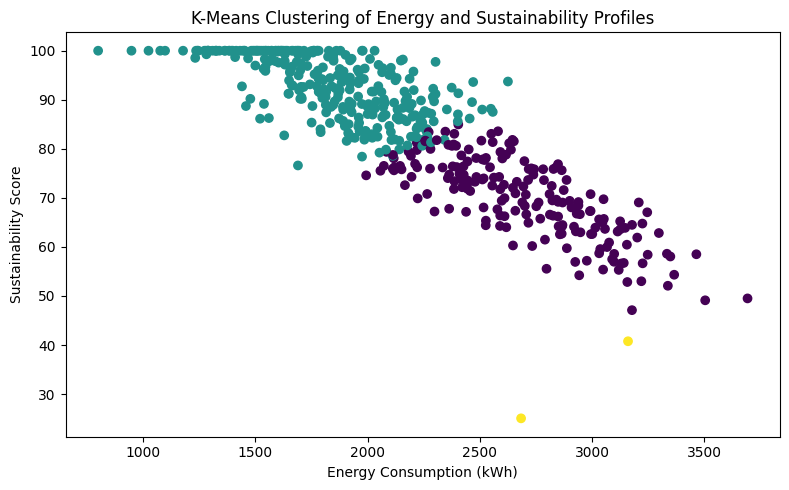


ASSOCIATION RULES

          Antecedent        Consequent  Support  Confidence   Lift
9            High_AC   High_Energy_Use    0.138       0.340  1.133
3        EV_Charging   High_Energy_Use    0.080       0.333  1.111
0        EV_Charging  Solar_Generation    0.072       0.300  1.079
5   Solar_Generation      High_Traffic    0.114       0.410  1.046
11      High_Traffic   High_Energy_Use    0.118       0.301  1.003
1        EV_Charging           High_AC    0.096       0.400  0.985
8            High_AC      High_Traffic    0.156       0.384  0.980
2        EV_Charging      High_Traffic    0.092       0.383  0.978
7            High_AC        High_Waste    0.062       0.153  0.967
10        High_Waste      High_Traffic    0.058       0.367  0.936

PROGRAM COMPLETED SUCCESSFULLY

Files Created:
1. sseip_sample_dataset.csv
2. SSEIP_Final_Output.csv

Graphs Generated Successfully
Final Confusion Matrix Generated Successfully


In [ ]:
# ============================================================
# SMART SUSTAINABLE CITY ENERGY INTELLIGENCE PLATFORM (SSEIP)
# Data Warehousing and Data Mining Assignment
#
# Algorithms Used:
# 1. Random Forest Classification
# 2. K-Means Clustering
# 3. Association Rule Mining
#
# Graphs:
# - Energy Consumption Distribution
# - Classification Metrics
# - Silhouette Score
# - Cluster Visualization
# - Confusion Matrix
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
# ============================================================
# 1. CREATE SAMPLE DATASET
# ============================================================
np.random.seed(42)
n = 500
# Zone
zones = np.random.choice(
    ['North', 'South', 'East', 'West', 'Central'],
    n
)
# Building Type
building_type = np.random.choice(
    ['Residential', 'Commercial', 'Public'],
    n,
    p=[0.5, 0.3, 0.2]
)
# Temperature
temperature = np.random.normal(31, 3, n)
temperature = np.clip(temperature, 22, 42)
# Occupancy
occupancy = np.random.randint(20, 100, n)
# Solar Capacity
solar_capacity = np.random.gamma(2, 4, n)
solar_capacity = np.clip(solar_capacity, 0, 30)
# Traffic Index
traffic_index = np.random.randint(100, 2000, n)
# EV Charging Sessions
ev_sessions = np.random.poisson(8, n)
# Waste Generated
waste_generated = np.random.normal(900, 300, n)
waste_generated = np.clip(waste_generated, 100, 2500)
# ============================================================
# 2. GENERATE ENERGY CONSUMPTION
# ============================================================
base_energy = np.zeros(n)
for i in range(n):
    if building_type[i] == 'Residential':
        base_energy[i] = 900
    elif building_type[i] == 'Commercial':
        base_energy[i] = 1800
    else:
        base_energy[i] = 1400
energy_consumption = (
    base_energy
    + occupancy * 9
    + temperature * 18
    - solar_capacity * 32
    + ev_sessions * 14
    + np.random.normal(0, 180, n)
)
energy_consumption = np.clip(
    energy_consumption,
    300,
    None
)
# ============================================================
# 3. RENEWABLE ENERGY PERCENTAGE
# ============================================================
renewable_percent = (
    solar_capacity * 35
    + np.random.normal(8, 4, n)
)
renewable_percent = (
    renewable_percent
    / np.maximum(energy_consumption / 1000, 1)
    * 10
)
renewable_percent = np.clip(
    renewable_percent,
    0,
    100
)
# ============================================================
# 4. SUSTAINABILITY SCORE
# ============================================================
sustainability_score = (
    100
    - (energy_consumption / 40)
    - (waste_generated / 80)
    + renewable_percent * 0.5
    + np.random.normal(0, 5, n)
)
sustainability_score = np.clip(
    sustainability_score,
    0,
    100
)
# ============================================================
# 5. CREATE TARGET VARIABLE
# HIGH ENERGY NEXT CYCLE
# ============================================================
energy_threshold = np.percentile(
    energy_consumption,
    70
)
high_energy_next_cycle = (
    energy_consumption > energy_threshold
).astype(int)

# ============================================================
# 6. CREATE DATAFRAME
# ============================================================
df = pd.DataFrame({
    'Zone': zones,
    'Building_Type': building_type,
    'Temperature_C': temperature,
    'Occupancy_Rate': occupancy,
    'Solar_Capacity_kW': solar_capacity,
    'Traffic_Index': traffic_index,
    'EV_Charging_Sessions': ev_sessions,
    'Waste_Generated_kg': waste_generated,
    'Energy_Consumption_kWh': energy_consumption,
    'Renewable_Energy_Percent': renewable_percent,
    'Sustainability_Score': sustainability_score,
    'High_Energy_Next_Cycle': high_energy_next_cycle
})
# ============================================================
# 7. SAVE DATASET
# ============================================================
df.to_csv(
    "sseip_sample_dataset.csv",
    index=False
)
print("Dataset Created Successfully")
print()
print(df.head())
print()
print("Dataset Shape:", df.shape)
# ============================================================
# GRAPH 1
# ENERGY CONSUMPTION DISTRIBUTION
# ============================================================
plt.figure(figsize=(8, 5))
plt.hist(
    df['Energy_Consumption_kWh'],
    bins=25,
    edgecolor='black'
)
plt.xlabel("Energy Consumption (kWh)")
plt.ylabel("Number of Buildings")
plt.title("Distribution of Energy Consumption")
plt.tight_layout()
plt.show()
# ============================================================
# RANDOM FOREST CLASSIFICATION
# CO3
# ============================================================
features = [
    'Temperature_C',
    'Occupancy_Rate',
    'Solar_Capacity_kW',
    'Traffic_Index',
    'EV_Charging_Sessions',
    'Waste_Generated_kg',
    'Energy_Consumption_kWh',
    'Renewable_Energy_Percent',
    'Sustainability_Score'

]
X = df[features]
y = df['High_Energy_Next_Cycle']
# ============================================================
# TRAIN TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)
# ============================================================
# CREATE RANDOM FOREST MODEL
# ============================================================
model = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    class_weight='balanced'
)
# ============================================================
# TRAIN MODEL
# ============================================================
model.fit(
    X_train,
    y_train
)
# ============================================================
# PREDICTION
# ============================================================
y_pred = model.predict(
    X_test
)
# ============================================================
# CLASSIFICATION METRICS
# ============================================================
accuracy = accuracy_score(
    y_test,
    y_pred
)
precision = precision_score(
    y_test,
    y_pred
)
recall = recall_score(
    y_test,
    y_pred
)
f1 = f1_score(
    y_test,
    y_pred
)
print()
print("=================================")
print("RANDOM FOREST CLASSIFICATION")
print("=================================")
print()
print("Accuracy:", round(accuracy, 3))
print("Precision:", round(precision, 3))
print("Recall:", round(recall, 3))
print("F1 Score:", round(f1, 3))
# ============================================================
# GRAPH 2
# CLASSIFICATION PERFORMANCE
# ============================================================
metric_names = [
    'Accuracy',
    'Precision',
    'Recall',
    'F1 Score'
]
metric_values = [
    accuracy,
    precision,
    recall,
    f1
]
plt.figure(figsize=(8, 5))
plt.bar(
    metric_names,
    metric_values
)
plt.ylim(
    0,
    1
)
plt.xlabel(
    "Performance Metrics"
)
plt.ylabel(
    "Score"
)
plt.title(
    "Random Forest Classification Performance"
)
plt.tight_layout()
plt.show()
# ============================================================
# FINAL CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(
    y_test,
    y_pred,
)
print()
print("=================================")
print("CONFUSION MATRIX")
print("=================================")
print(cm)
# ============================================================
# GRAPH 3
# CONFUSION MATRIX GRAPH
# ============================================================
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'Normal Energy',
        'High Energy'
    ]
)
plt.figure(figsize=(7, 5))
disp.plot()
plt.title(
    "Confusion Matrix - Random Forest Classification"

)
plt.tight_layout()
plt.show()
# ============================================================
# K-MEANS CLUSTERING
# CO4
# ============================================================
cluster_features = [
    'Energy_Consumption_kWh',
    'Waste_Generated_kg',
    'Renewable_Energy_Percent',
    'EV_Charging_Sessions',
    'Sustainability_Score'
]
cluster_data = df[
    cluster_features

]
# ============================================================
# STANDARDIZATION
# ============================================================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(
    cluster_data
)
# ============================================================
# FIND BEST K USING SILHOUETTE SCORE
# ============================================================
silhouette_scores = []
k_values = []
for k in range(2, 7):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )
    labels = kmeans.fit_predict(
        scaled_data
    )
    score = silhouette_score(
        scaled_data,
        labels
    )
    k_values.append(k)
    silhouette_scores.append(score)
    print(
        "K =",
        k,
        "Silhouette Score =",
        round(score, 3)
    )
# ============================================================
# FIND BEST K
# ============================================================
best_index = np.argmax(
    silhouette_scores
)
best_k = k_values[
    best_index
]
print()
print(
    "Best Number of Clusters:",
    best_k
)
# ============================================================
# GRAPH 4
# SILHOUETTE SCORE GRAPH
# ============================================================
plt.figure(figsize=(8, 5))
plt.plot(
    k_values,
    silhouette_scores,
    marker='o'
)
plt.xlabel(
    "Number of Clusters (K)"
)
plt.ylabel(
    "Silhouette Score"
)
plt.title(
    "Silhouette Score for Different K Values"
)
plt.xticks(
    k_values
)
plt.tight_layout()
plt.show()
# ============================================================
# FINAL K-MEANS MODEL
# ============================================================

final_kmeans = KMeans(

    n_clusters=best_k,

    random_state=42,

    n_init=20
)
df['Cluster'] = final_kmeans.fit_predict(
    scaled_data
)
print()
print("=================================")
print("CLUSTER SUMMARY")
print("=================================")
print()
cluster_summary = df.groupby(
    'Cluster'
)[
    cluster_features
].mean()
print(
    cluster_summary.round(2)
)
# ============================================================
# GRAPH 5
# CLUSTER VISUALIZATION
# ============================================================
plt.figure(figsize=(8, 5))
plt.scatter(
    df['Energy_Consumption_kWh'],
    df['Sustainability_Score'],
    c=df['Cluster']
)
plt.xlabel(
    "Energy Consumption (kWh)"
)
plt.ylabel(
    "Sustainability Score"
)
plt.title(
    "K-Means Clustering of Energy and Sustainability Profiles"
)
plt.tight_layout()
plt.show()
# ============================================================
# ASSOCIATION RULE MINING
# CO5
# ============================================================
activities = []
for i in range(len(df)):
    transaction = []
    # High AC / Temperature
    if df.loc[i, 'Temperature_C'] > 32:
        transaction.append(
            'High_AC'
        )
    # EV Charging
    if df.loc[i, 'EV_Charging_Sessions'] >= 10:
        transaction.append(
            'EV_Charging'
        )
    # High Traffic
    if df.loc[i, 'Traffic_Index'] > 1200:
        transaction.append(
            'High_Traffic'
        )
    # High Energy
    if df.loc[i, 'High_Energy_Next_Cycle'] == 1:
        transaction.append(
            'High_Energy_Use'
        )
    # High Waste
    if df.loc[i, 'Waste_Generated_kg'] > 1200:
        transaction.append(
         'High_Waste'

        )
    # Solar Generation
    if df.loc[i, 'Solar_Capacity_kW'] > 10:
        transaction.append(
            'Solar_Generation'
        )
    # Normal Usage
    if len(transaction) == 0:
        transaction.append(
            'Normal_Usage'
        )
    activities.append(
        transaction
    )
# ============================================================
# ASSOCIATION RULE CALCULATION
# ============================================================
from itertools import combinations
all_items = set()
for transaction in activities:
    for item in transaction:
        all_items.add(item)
all_items = list(
    all_items
)
rules = []
total_transactions = len(
    activities
)
for item1, item2 in combinations(
    all_items,
    2
):
    count_item1 = sum(
        item1 in t
        for t in activities
    )
    count_item2 = sum(
        item2 in t
        for t in activities
    )
    count_both = sum(
        item1 in t
        and item2 in t
        for t in activities
    )
    support_item1 = (
        count_item1
        / total_transactions
    )
    support_item2 = (
        count_item2
        / total_transactions
    )
    support_both = (
        count_both
        / total_transactions
    )
    if support_both >= 0.05 and support_item1 > 0:
        confidence = (
            support_both
            / support_item1
        )
        lift = (
            confidence
            / support_item2
        )
        rules.append([
            item1,
            item2,
            support_both,
            confidence,
            lift
        ])
# ============================================================
# ASSOCIATION RULE DATAFRAME
# ============================================================
rules_df = pd.DataFrame(
    rules,
    columns=[
        'Antecedent',
        'Consequent',
        'Support',
        'Confidence',
        'Lift'
    ]
)
rules_df = rules_df.sort_values(
    by=[
        'Lift',
        'Confidence'
    ],
    ascending=False
)
print()
print("=================================")
print("ASSOCIATION RULES")
print("=================================")
print()
print(
    rules_df.head(10).round(3)
)
# ============================================================
# SAVE FINAL DATASET
# ============================================================
df.to_csv(
    "SSEIP_Final_Output.csv",
    index=False
)
print()
print("=================================")
print("PROGRAM COMPLETED SUCCESSFULLY")
print("=================================")
print()
print(
    "Files Created:"
)
print(

    "1. sseip_sample_dataset.csv"
)
print(

    "2. SSEIP_Final_Output.csv"
)
print()
print(
    "Graphs Generated Successfully"

)
print(
    "Final Confusion Matrix Generated Successfully"
)